In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, zscore
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import numpy as np

#### Figure 1C

In [2]:
#df_merged=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/FCNN_xgboost_ridge.csv",index_col='Unnamed: 0')
df_merged=pd.read_csv("/data/kumarr17/TxCyto/results/FCNN_xgboost_ridge.csv",index_col='Unnamed: 0')

FCNN vs XGBoost: 9.303547342603712e-90
FCNN vs Ridge: 3.2591999425547445e-107


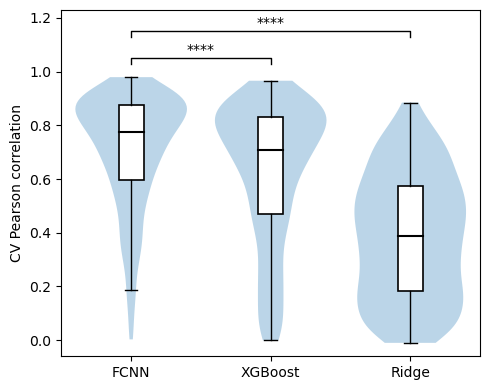

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import numpy as np

plot_df_v1 = df_merged[
    ['FCNN_CV', 'XGBoost_CV', 'Ridge_CV']
].dropna()

# --------------------------------------------------
# Paired Wilcoxon tests
# --------------------------------------------------

stat_xgb, p_xgb = wilcoxon(
    plot_df_v1['FCNN_CV'],
    plot_df_v1['XGBoost_CV']
)

stat_ridge, p_ridge = wilcoxon(
    plot_df_v1['FCNN_CV'],
    plot_df_v1['Ridge_CV']
)

print("FCNN vs XGBoost:", p_xgb)
print("FCNN vs Ridge:", p_ridge)


# --------------------------------------------------
# Convert p-value to significance stars
# --------------------------------------------------

def p_to_star(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


# --------------------------------------------------
# Prepare data
# --------------------------------------------------

data = [
    plot_df_v1['FCNN_CV'].values,
    plot_df_v1['XGBoost_CV'].values,
    plot_df_v1['Ridge_CV'].values
]

positions = [1, 2, 3]


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 4))

# Violin plots
vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Boxplots inside violins
ax.boxplot(
    data,
    positions=positions,
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(
        facecolor='white',
        edgecolor='black',
        linewidth=1.2
    ),
    medianprops=dict(
        color='black',
        linewidth=1.5
    ),
    whiskerprops=dict(
        color='black',
        linewidth=1
    ),
    capprops=dict(
        color='black',
        linewidth=1
    )
)

ax.set_xticks(positions)
ax.set_xticklabels(['FCNN', 'XGBoost', 'Ridge'])

ax.set_ylabel("CV Pearson correlation")


# --------------------------------------------------
# Significance brackets
# --------------------------------------------------

ymax = np.nanmax(plot_df_v1.values)

y1 = ymax + 0.05
y2 = ymax + 0.15

# FCNN vs XGBoost
ax.plot(
    [1, 1, 2, 2],
    [y1, y1 + 0.02, y1 + 0.02, y1],
    c='black',
    linewidth=1
)

ax.text(
    1.5,
    y1 + 0.025,
    p_to_star(p_xgb),
    ha='center',
    va='bottom'
)

# FCNN vs Ridge
ax.plot(
    [1, 1, 3, 3],
    [y2, y2 + 0.02, y2 + 0.02, y2],
    c='black',
    linewidth=1
)

ax.text(
    2,
    y2 + 0.025,
    p_to_star(p_ridge),
    ha='center',
    va='bottom'
)


# --------------------------------------------------
# Y-axis range
# --------------------------------------------------

ax.set_ylim(
    plot_df_v1.min().min() - 0.05,
    y2 + 0.10
)

plt.tight_layout()
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure1/FCNN_XGBoost_Ridge_violin.svg",
#    format="svg",
#    bbox_inches="tight"
#)
#plt.show()